In [ ]:
import sys, platform, hashlib, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)


df = pd.read_csv('/content/Telco-Customer-Churn.csv')

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Veri Yükleme**

In [ ]:
csv_yolu = "/content/Telco-Customer-Churn.csv"
hedef = "Churn"

def file_hash(path):  #Veri versiyonlama için md5 hash üretir.
   return hashlib.md5(open(path, 'rb').read()).hexdigest()

if csv_yolu:
  df = pd.read_csv(csv_yolu).copy()
  print(f"Veri {csv_yolu} | Hash (MD5): {file_hash(csv_yolu)}")
  assert hedef in df.columns, f"'{hedef}' sütunu bulunamadı: {list(df.columns)}"

else:
  from sklearn.datasets import load_breast_cancer
  df = load_breast_cancer(as_frame=True).frame.copy()
  hedef = "target"
  print("Uyarı: CSV verilmedi, örnek data seti olan Breast Cancer kullanılıyor.")


print(f"Gözlem sayısı: {len(df)} |   Değişken sayısı: {df.shape[1]}")
df.head()

Veri /content/Telco-Customer-Churn.csv | Hash (MD5): 3b0bfab28a8101b4e4fdd08025a5c235
Gözlem sayısı: 7043 |   Değişken sayısı: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Keşifsel Veri İnceleme **

In [ ]:
df.describe().T.head(20)


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


Eksik değer dağılımı:  0

Sınıf dağılımı: 
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


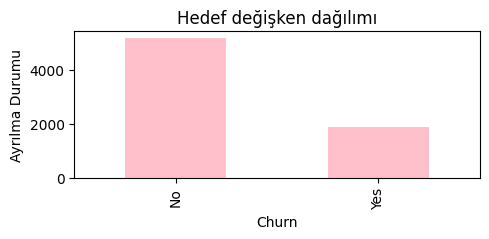

Uyarı: Küçük örneklem (n<30) - güç analizi yapıldı mı?


In [ ]:
#Eksik değer ve sınıf dağılımlarına bakalım

print("Eksik değer dağılımı: ", df.isnull().sum().sum())
dagilim = df[hedef].value_counts(normalize = True)
print("\nSınıf dağılımı: ")
print(dagilim.round(3))

fig, ax = plt.subplots(figsize = (5, 2.5))
df[hedef].value_counts().plot(kind="bar", color="pink", ax=ax)
ax.set_title("Hedef değişken dağılımı"); ax.set_xlabel(hedef);ax.set_ylabel("Ayrılma Durumu")
plt.tight_layout();plt.show()

if dagilim.min() < 0.2:
  print("Uyarı: Sınıf dengesizliği mevcut. class_weight='balanced' kullanılacak.")
if len(df) > 0.2:
  print("Uyarı: Küçük örneklem (n<30) - güç analizi yapıldı mı?")

**Ön İşleme**

In [ ]:
from pandas.core.dtypes.api import is_numeric_dtype
for col in df.columns:
  if df[col].isnull().any():
      if pd.api.types.is_numeric_dtype(df[col]):
         df[col] = df[col].fillna(df[col].median())
      else:
         df[col] = df[col].fillna(df[col].mode()[0])


y = df[hedef]
x = pd.get_dummies(df.drop(columns=[hedef]), drop_first=True)


if not pd.api.types.is_numeric_dtype(y):
  y = pd.Series(LabelEncoder().fit_transform(y), name=hedef)
  print("Hedef değişken sayısal olarak kodlandı(LabelEncoder): ")


print(f"Özellik matrisi: {x.shape}   | Hedef: {y.shape}")


Hedef değişken sayısal olarak kodlandı(LabelEncoder): 
Özellik matrisi: (7043, 13601)   | Hedef: (7043,)


**Eğitim/Test Ayrımı**

In [ ]:
x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
    )
print(f"Eğitim seti: {len(x_tr)}   |  Test seti: {len(x_te)}")

Eğitim seti: 5634   |  Test seti: 1409


**Model Eğitimi ve Değerlendirme**

In [ ]:
SEED = 42

def degerlendir(model,ad):
  model.fit(x_tr, y_tr)
  y_pred = model.predict(x_te)

  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  cv_skor = cross_val_score(model, x_tr, y_tr, cv=cv, scoring="accuracy")

  m = {
        "Model": ad,
        "Doğruluk (Accuracy)": accuracy_score(y_te, y_pred),
        "Kesinlik (Precision)": precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "Duyarlılık (Recall)": recall_score(y_te, y_pred, average="weighted"),
        "F1 Skoru": f1_score(y_te, y_pred, average="weighted"),
        "CV Ortalama": cv_skor.mean(),
        "CV Std": cv_skor.std(),
  }
  if len(np.unique(y_tr)) == 2:
        m["ROC-AUC"] = roc_auc_score(y_te, model.predict_proba(x_te)[:, 1])

  print(f"--- {ad} ---")
  print(classification_report(y_te, y_pred, zero_division=0))
  return model, y_pred, m

dt_model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                                  class_weight="balanced", random_state=SEED)
rf_model = RandomForestClassifier(n_estimators=250, min_samples_leaf=4,
                                  class_weight="balanced", n_jobs=-1, random_state=SEED)

dt, dt_pred, dt_m = degerlendir(dt_model, "Decision Tree")
rf, rf_pred, rf_m = degerlendir(rf_model, "Random Forest")

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.91      0.65      0.76      1035
           1       0.46      0.82      0.59       374

    accuracy                           0.69      1409
   macro avg       0.68      0.73      0.67      1409
weighted avg       0.79      0.69      0.71      1409



**Karşılaştırma Tablosu**

In [ ]:
tablo = pd.DataFrame([dt_m, rf_m]).set_index("Model").round(4)
tablo.to_csv("model_karsilastirma.csv")
tablo

,Doğruluk (Accuracy),Kesinlik (Precision),Duyarlılık (Recall),F1 Skoru,CV Ortalama,CV Std,ROC-AUC
Model,,,,,,,
Decision Tree,0.7374,0.8050,0.7374,0.7519,0.7238,0.0081,0.8285
Random Forest,0.6927,0.7888,0.6927,0.7106,0.6771,0.0201,0.8056


**Görselleştirme**

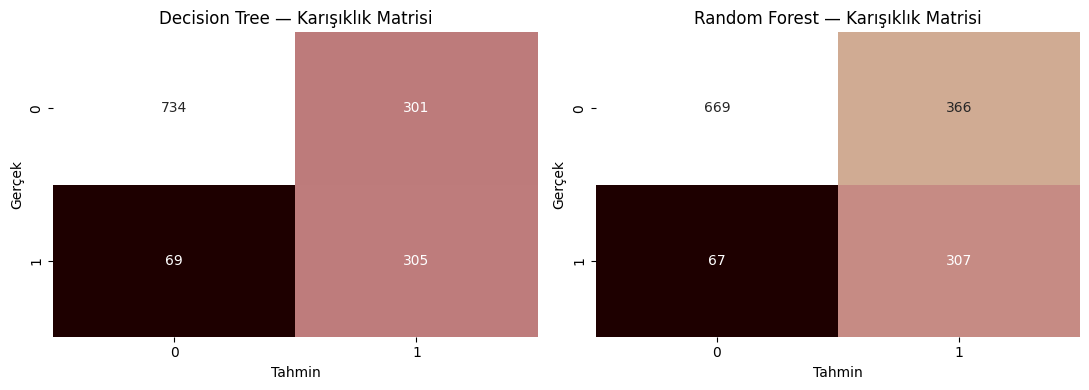

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (ad, pred) in zip(axes, [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="pink", ax=ax, cbar=False)
    ax.set_title(f"{ad} — Karışıklık Matrisi")
    ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
plt.tight_layout(); plt.show()

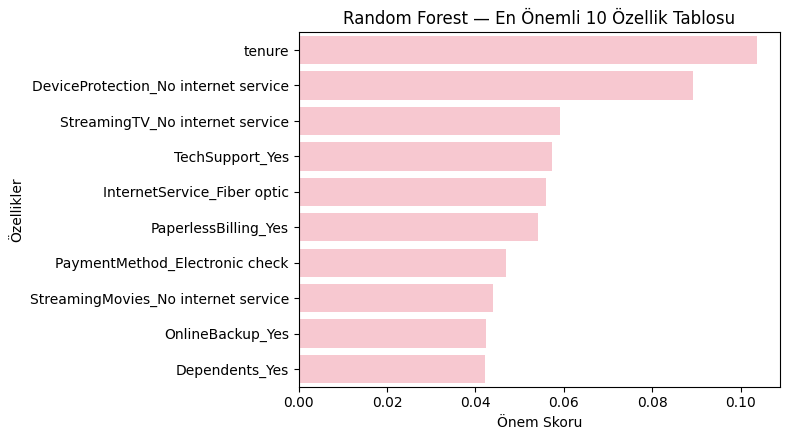

In [ ]:
# Random Forest özellik önemleri (ilk 10)
onem = pd.Series(rf.feature_importances_, index=x.columns).nlargest(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=onem.values, y=onem.index, color="pink", ax=ax)
ax.set_title("Random Forest — En Önemli 10 Özellik Tablosu"); ax.set_xlabel("Önem Skoru");ax.set_ylabel("Özellikler");
plt.tight_layout(); plt.show()

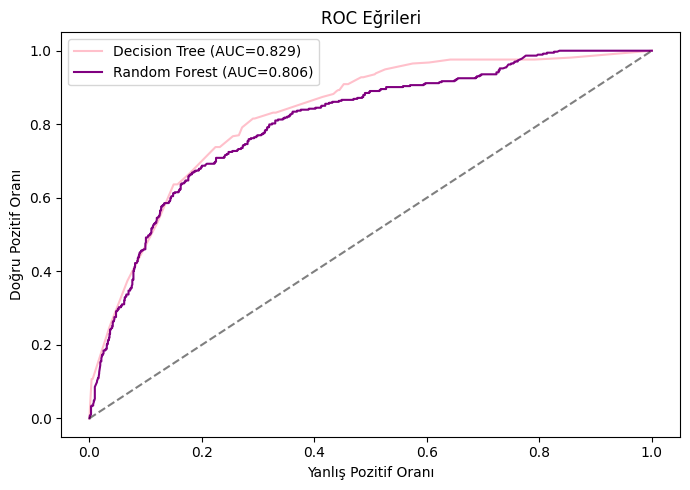

In [ ]:
# ROC eğrileri (yalnızca ikili sınıflandırmada)
if len(np.unique(y_te)) == 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ['pink', 'purple'] # Define colors for the plots
    for i, (model, ad) in enumerate([(dt, "Decision Tree"), (rf, "Random Forest")]):
        proba = model.predict_proba(x_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, proba)
        ax.plot(fpr, tpr, label=f"{ad} (AUC={roc_auc_score(y_te, proba):.3f})", color=colors[i])
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title("ROC Eğrileri")
    ax.set_xlabel("Yanlış Pozitif Oranı"); ax.set_ylabel("Doğru Pozitif Oranı")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print("Çok sınıflı problem: ROC eğrisi atlandı.")

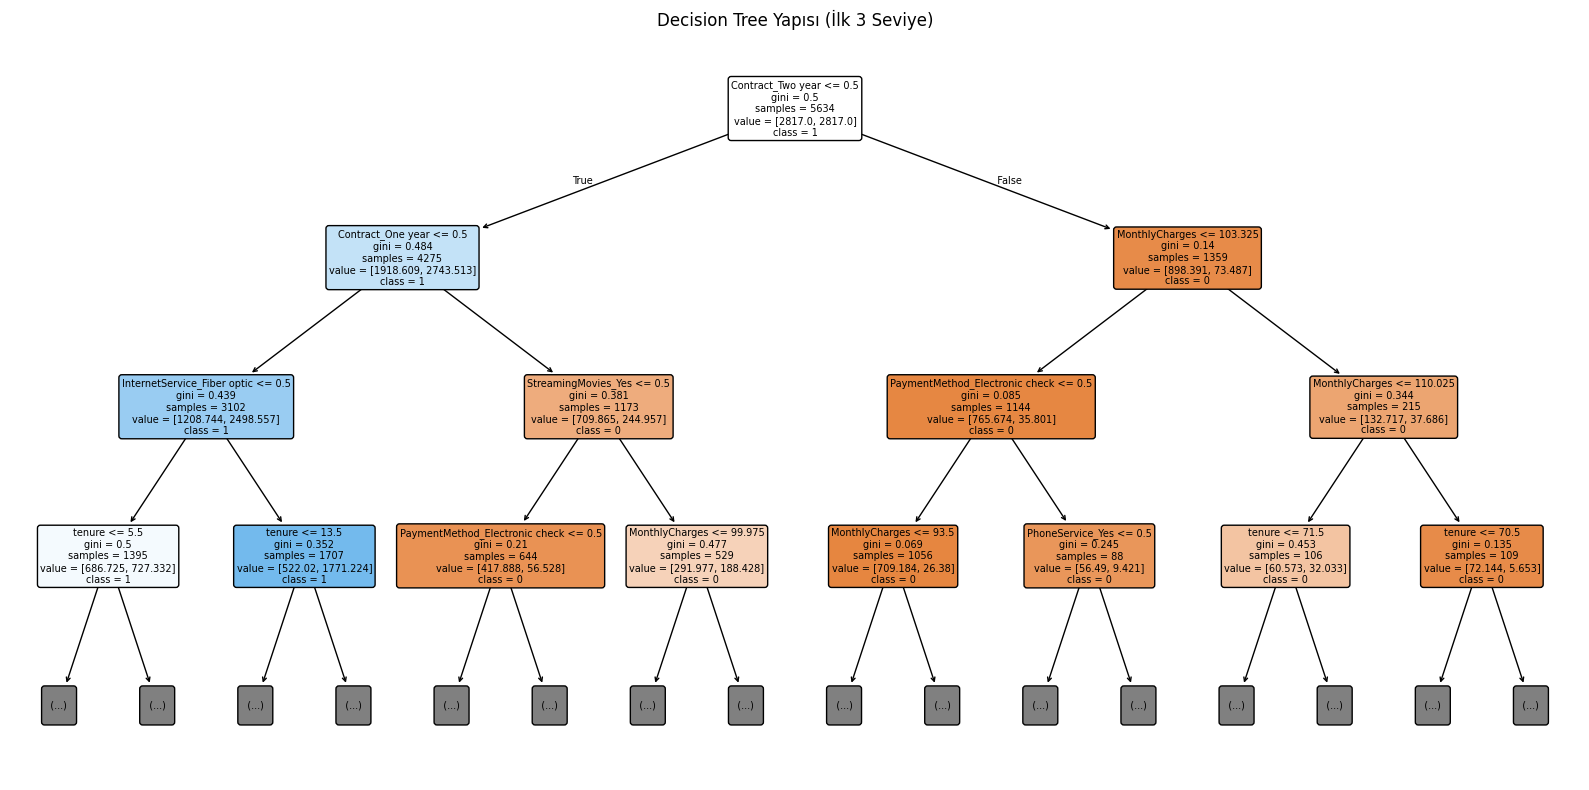

In [ ]:
# Karar ağacı yapısı (yorumlanabilirlik için ilk 3 seviye)
import matplotlib.pyplot as plt
from cycler import cycler

# Orijinal renk döngüsünü sakla
original_prop_cycle = plt.rcParams['axes.prop_cycle']

# Pembe tonlarını içeren yeni bir renk döngüsü ayarla
plt.rcParams['axes.prop_cycle'] = cycler(color=['pink', 'green'])

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(dt, max_depth=3, feature_names=list(x.columns), filled=True,
          fontsize=7, ax=ax, class_names=[str(cl) for cl in np.unique(y_te)],
          proportion=False, rounded=True)
ax.set_title("Decision Tree Yapısı (İlk 3 Seviye)")
plt.tight_layout(); plt.show()

# Orijinal renk döngüsünü geri yükle (isteğe bağlı ama iyi bir uygulama)
plt.rcParams['axes.prop_cycle'] = original_prop_cycle

**Raporlama Bloğu**

In [ ]:
kazanan = tablo["F1 Skoru"].idxmax()
rapor = (
    f"Karar ağacı modeli test setinde %{dt_m['Doğruluk (Accuracy)']*100:.1f} doğruluk "
    f"(F1 = {dt_m['F1 Skoru']:.3f}), rastgele orman modeli ise "
    f"%{rf_m['Doğruluk (Accuracy)']*100:.1f} doğruluk (F1 = {rf_m['F1 Skoru']:.3f}) "
    f"elde etmiştir. 5-katlı çapraz doğrulamada ortalama doğruluk sırasıyla "
    f"{dt_m['CV Ortalama']:.3f} (SS = {dt_m['CV Std']:.3f}) ve "
    f"{rf_m['CV Ortalama']:.3f} (SS = {rf_m['CV Std']:.3f}) olarak bulunmuştur. "
    f"Genel performans açısından {kazanan} modeli daha başarılıdır."
)
print(rapor)

Karar ağacı modeli test setinde %73.7 doğruluk (F1 = 0.752), rastgele orman modeli ise %69.3 doğruluk (F1 = 0.711) elde etmiştir. 5-katlı çapraz doğrulamada ortalama doğruluk sırasıyla 0.724 (SS = 0.008) ve 0.677 (SS = 0.020) olarak bulunmuştur. Genel performans açısından Decision Tree modeli daha başarılıdır.
